# Visualizations to strengthen the theoretical understanding

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

import os

In [12]:
def plot_sine_waves(
    freq1=1.0, amp1=2.0, phase1=90.0,
    freq2=3.0, amp2=0.5, phase2=0.0,
    duration=0.5, sample_rate=1000
):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    t_rad = 2 * np.pi * t

    wave1 = amp1 * np.sin(2 * np.pi * freq1 * t_rad + np.radians(phase1))
    wave2 = amp2 * np.sin(2 * np.pi * freq2 * t_rad + np.radians(phase2))
    wave_sum = wave1 + wave2

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(t_rad, wave1, color='steelblue')
    axes[0].plot(t_rad, wave2, color='coral')
    axes[0].set_title(f'Blue Wave — freq: {freq1} Hz, amp: {amp1}, phase: {phase1}° \n Orange Wave — freq: {freq2} Hz, amp: {amp2}, phase: {phase2}°')

    axes[1].plot(t_rad, wave_sum, color='gray')
    axes[1].set_title('Sum')

    for ax in axes:
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_ylabel('Amplitude')

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

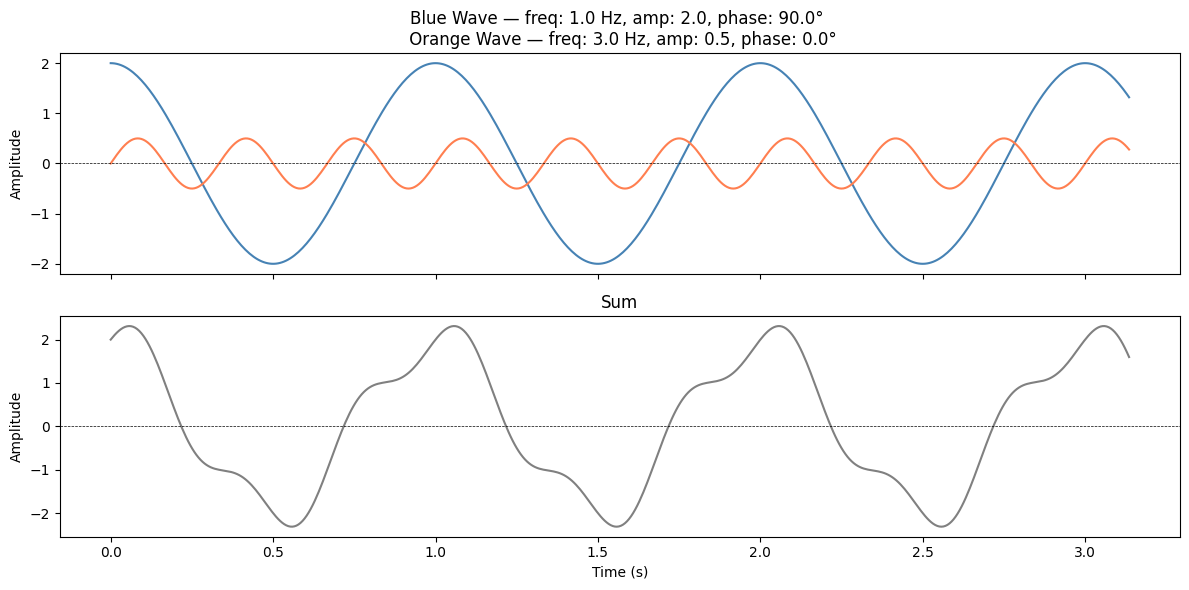

In [13]:
plot_sine_waves()

In [35]:
def plot_sine_waves(
    freq1=1.0, amp1=2.0, phase1=90.0,
    freq2=3.0, amp2=0.5, phase2=0.0,
    duration=0.5, sample_rate=1000
):
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    t_rad = 2 * np.pi * t

    wave1 = amp1 * np.sin(2 * np.pi * freq1 * t_rad + np.radians(phase1))
    wave2 = amp2 * np.sin(2 * np.pi * freq2 * t_rad + np.radians(phase2))
    wave_dot = wave1 * wave2

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    axes[0].plot(t_rad, wave1, color='steelblue')
    axes[0].plot(t_rad, wave2, color='coral')
    axes[0].set_title(f'Blue Wave — freq: {freq1} Hz, amp: {amp1}, phase: {phase1}° \n Orange Wave — freq: {freq2} Hz, amp: {amp2}, phase: {phase2}°')

    axes[1].plot(t_rad, wave_dot, color='gray')
    axes[1].set_title('Product')

    for ax in axes:
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_ylabel('Amplitude')

    axes[1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

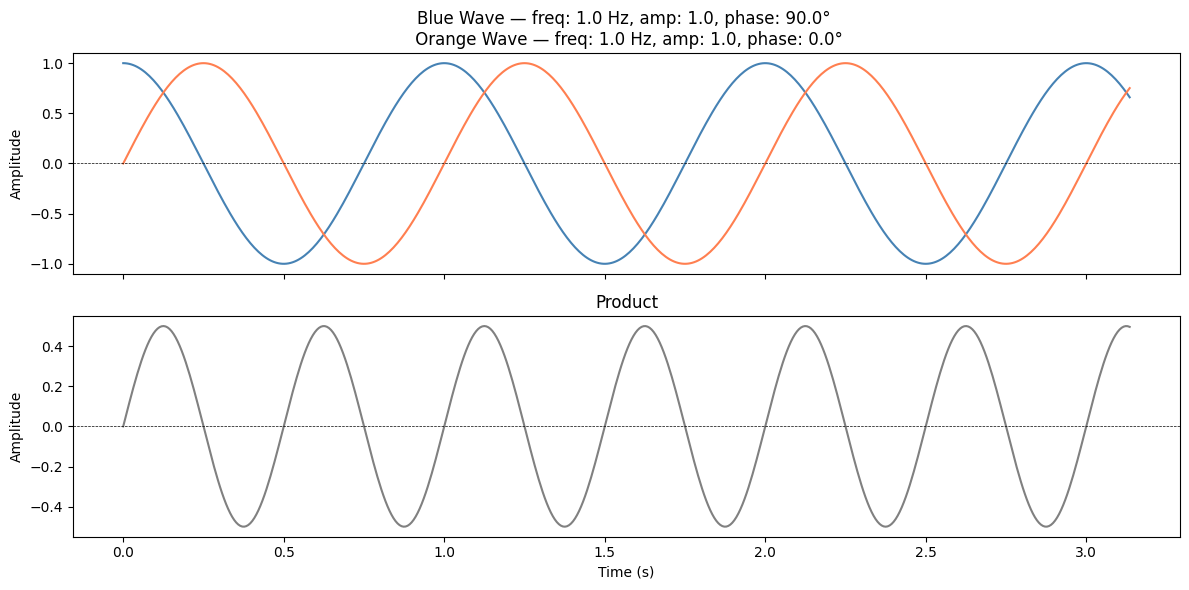

In [36]:
plot_sine_waves(freq1=1.0, amp1=1.0, phase1=90.0,
                freq2=1.0, amp2=1.0, phase2=0.0,
                duration=0.5, sample_rate=1000)

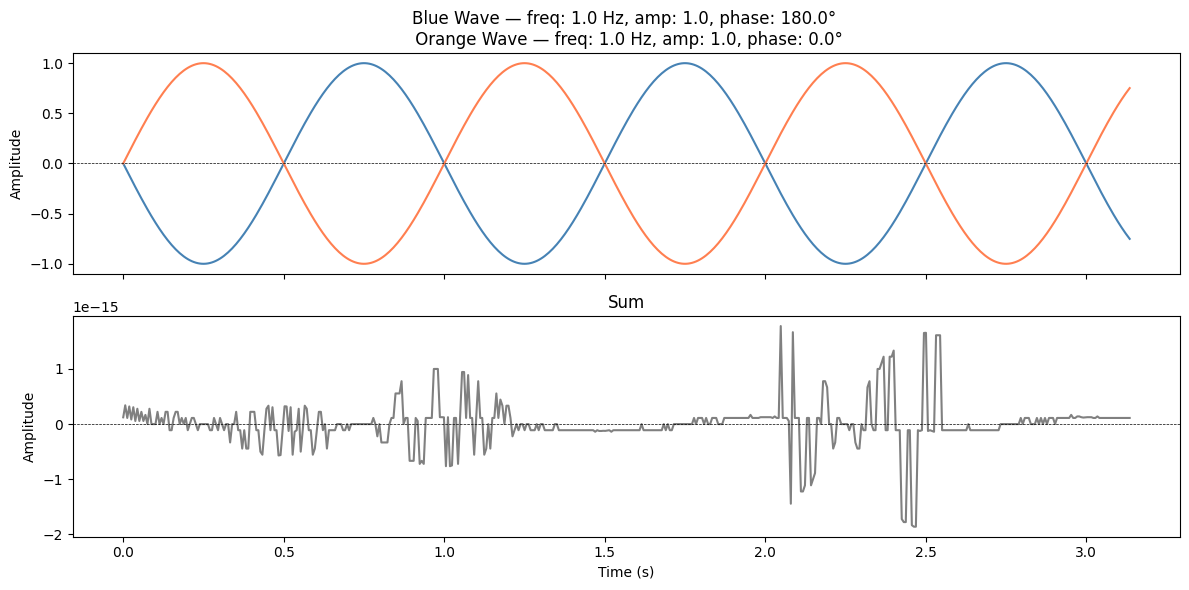

In [25]:
plot_sine_waves(freq1=1.0, amp1=1.0, phase1=180.0,
                freq2=1.0, amp2=1.0, phase2=0.0,
                duration=0.5, sample_rate=1000)

In [30]:
t = np.linspace(0, 1, 10000, endpoint=False)
t_rad = 2 * np.pi * t

wave1 = np.sin(2 * np.pi * t_rad + np.radians(0))
wave2 = np.sin(2 * np.pi * t_rad + np.radians(90))

In [32]:
print(wave1@wave1)
print(wave1@wave2)

5025.170534431643
121.32512269241657


In [1]:
def plot_nyquist_aliasing(
    f_low=3.0,
    sample_rate=8.0,
    duration=1.0,
    n_periods_hires=1000
):
    """
    Demonstrates aliasing by showing a low-frequency sine wave and a 
    high-frequency alias that produces identical values at the sampling points.
    
    f_low       : frequency below Nyquist (Hz)
    sample_rate : sampling rate fs (Hz). Nyquist = fs/2
    duration    : signal duration in seconds
    n_periods_hires : points for the continuous approximation
    """
    nyquist = sample_rate / 2
    f_high = f_low + sample_rate  # alias frequency: always f_low + k*fs

    t_cont = np.linspace(0, duration, n_periods_hires, endpoint=False)
    t_samp = np.arange(0, duration, 1 / sample_rate)  # actual sampling points

    wave_low  = np.sin(2 * np.pi * f_low  * t_cont)
    wave_high = np.sin(2 * np.pi * f_high * t_cont)
    samp_low  = np.sin(2 * np.pi * f_low  * t_samp)
    samp_high = np.sin(2 * np.pi * f_high * t_samp)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # --- top panel: low frequency (below Nyquist) ---
    axes[0].plot(t_cont, wave_low, color='steelblue', label=f'f = {f_low} Hz (below Nyquist)')
    axes[0].scatter(t_samp, samp_low, color='black', zorder=5, s=40, label='Sampling points')
    axes[0].vlines(t_samp, 0, samp_low, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    axes[0].set_title(
        f'Below Nyquist — f = {f_low} Hz  |  fs = {sample_rate} Hz  |  Nyquist = {nyquist} Hz',
        fontsize=10
    )
    axes[0].set_ylabel('Amplitude')
    axes[0].legend(fontsize=9)

    # --- bottom panel: alias frequency (above Nyquist) ---
    axes[1].plot(t_cont, wave_high, color='coral',     label=f'f = {f_high} Hz (above Nyquist, alias)')
    axes[1].plot(t_cont, wave_low,  color='steelblue', label=f'f = {f_low} Hz (below Nyquist)',
                 linestyle='--', alpha=0.4)
    axes[1].scatter(t_samp, samp_high, color='black', zorder=5, s=40, label='Sampling points')
    axes[1].vlines(t_samp, 0, samp_high, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    axes[1].set_title(
        f'Above Nyquist — f = {f_high} Hz  |  Sampling points identical to {f_low} Hz',
        fontsize=10
    )
    axes[1].set_ylabel('Amplitude')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(fontsize=9)

    plt.suptitle('Nyquist aliasing — identical samples, different signals', fontsize=11)
    plt.tight_layout()
    plt.show()

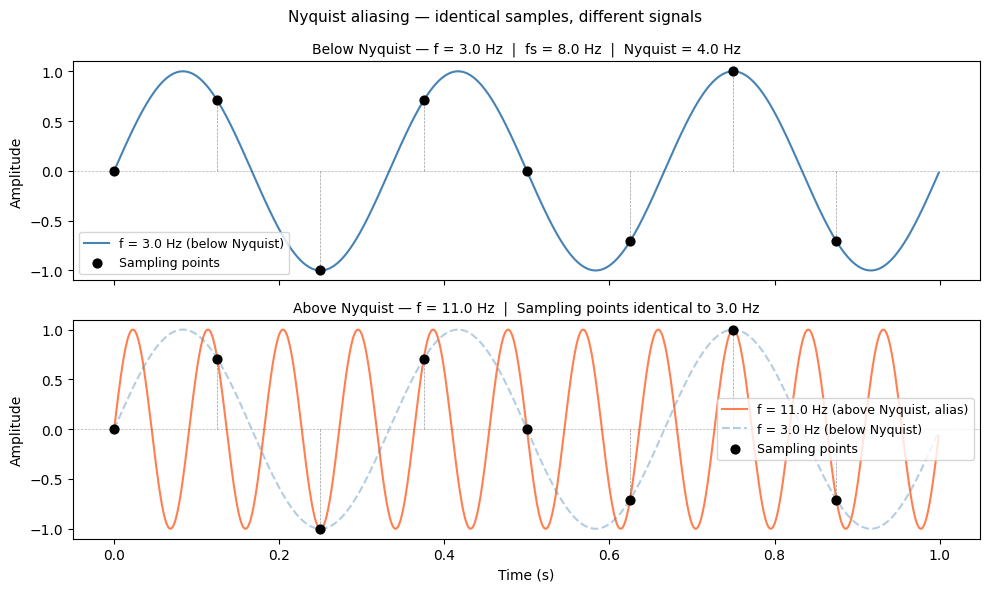

In [4]:
plot_nyquist_aliasing(f_low=3.0, sample_rate=8.0)

C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_34104\1850843515.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row, col].legend(fontsize=7, loc='upper right')


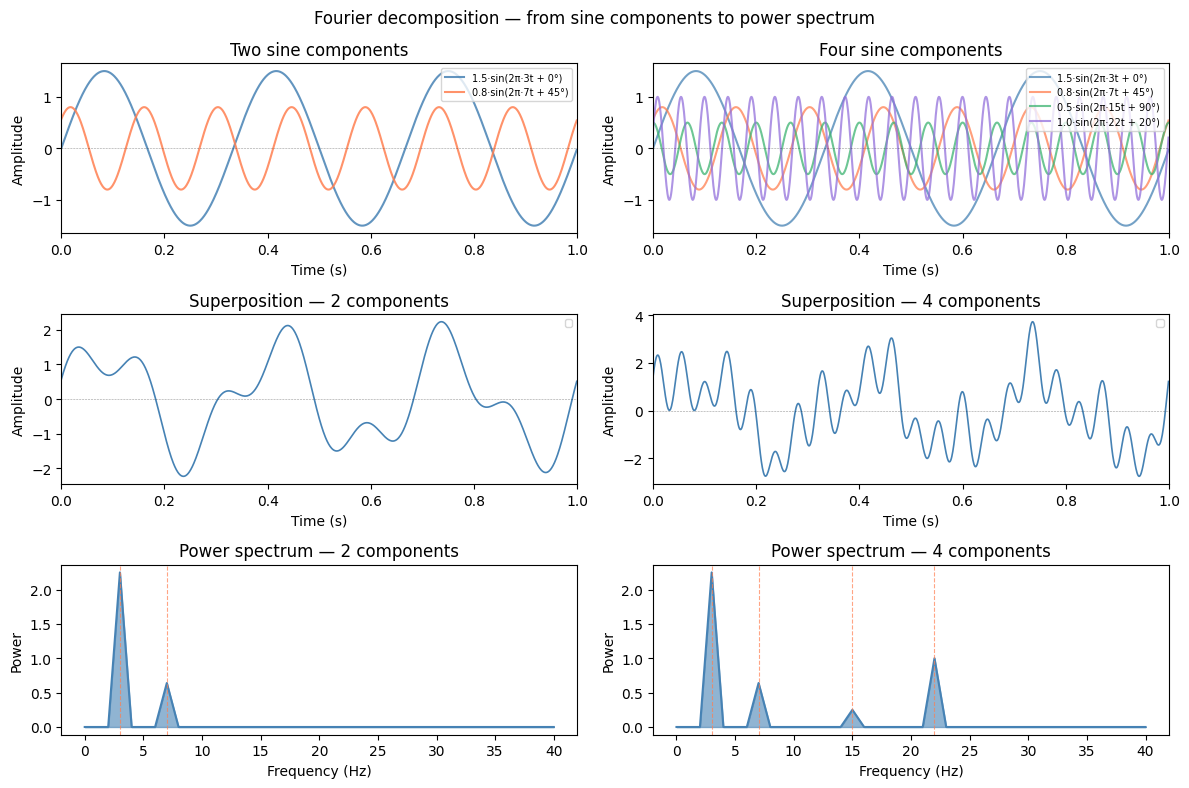

In [5]:
def plot_fourier_intuition():
    fs = 1000
    duration = 1.0
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    N = len(t)
    freqs = np.fft.rfftfreq(N, 1/fs)

    # --- define component waves ---
    waves_simple = [
        (1.5, 3, 0),    # amp, freq, phase
        (0.8, 7, 45),
    ]
    waves_complex = [
        (1.5, 3,  0),
        (0.8, 7,  45),
        (0.5, 15, 90),
        (1.0, 22, 20),
    ]

    def make_wave(components):
        return sum(a * np.sin(2 * np.pi * f * t + np.radians(p))
                   for a, f, p in components)

    def power_spectrum(wave):
        X = np.fft.rfft(wave)
        return freqs, (np.abs(X) / (N / 2)) ** 2

    simple_waves   = [make_wave([(a, f, p)]) for a, f, p in waves_simple]
    complex_waves  = [make_wave([(a, f, p)]) for a, f, p in waves_complex]
    sum_simple     = make_wave(waves_simple)
    sum_complex    = make_wave(waves_complex)
    f_simple,  p_simple  = power_spectrum(sum_simple)
    f_complex, p_complex = power_spectrum(sum_complex)

    colors_simple  = ['steelblue', 'coral']
    colors_complex = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

    fig, axes = plt.subplots(3, 2, figsize=(12, 8))

    # --- row 0: individual components ---
    for wave, (a, f, p), color in zip(simple_waves, waves_simple, colors_simple):
        axes[0, 0].plot(t, wave, color=color, alpha=0.85,
                        label=f'{a}·sin(2π·{f}t + {p}°)')
    axes[0, 0].set_title('Two sine components')

    for wave, (a, f, p), color in zip(complex_waves, waves_complex, colors_complex):
        axes[0, 1].plot(t, wave, color=color, alpha=0.75,
                        label=f'{a}·sin(2π·{f}t + {p}°)')
    axes[0, 1].set_title('Four sine components')

    # --- row 1: summed signal ---
    axes[1, 0].plot(t, sum_simple, color='steelblue', linewidth=1.2)
    axes[1, 0].set_title('Superposition — 2 components')

    axes[1, 1].plot(t, sum_complex, color='steelblue', linewidth=1.2)
    axes[1, 1].set_title('Superposition — 4 components')

    # --- row 2: power spectrum ---
    max_freq = 40
    mask = f_simple <= max_freq

    axes[2, 0].fill_between(f_simple[mask], p_simple[mask],
                             color='steelblue', alpha=0.6)
    axes[2, 0].plot(f_simple[mask], p_simple[mask], color='steelblue')
    for _, f, _ in waves_simple:
        axes[2, 0].axvline(f, color='coral', linewidth=0.8,
                           linestyle='--', alpha=0.7)
    axes[2, 0].set_title('Power spectrum — 2 components')
    axes[2, 0].set_xlabel('Frequency (Hz)')
    axes[2, 0].set_ylabel('Power')

    axes[2, 1].fill_between(f_complex[mask], p_complex[mask],
                             color='steelblue', alpha=0.6)
    axes[2, 1].plot(f_complex[mask], p_complex[mask], color='steelblue')
    for _, f, _ in waves_complex:
        axes[2, 1].axvline(f, color='coral', linewidth=0.8,
                           linestyle='--', alpha=0.7)
    axes[2, 1].set_title('Power spectrum — 4 components')
    axes[2, 1].set_xlabel('Frequency (Hz)')
    axes[2, 1].set_ylabel('Power')

    # --- shared formatting ---
    for row in range(2):
        for col in range(2):
            axes[row, col].set_xlim(0, duration)
            axes[row, col].set_xlabel('Time (s)')
            axes[row, col].set_ylabel('Amplitude')
            axes[row, col].axhline(0, color='black', linewidth=0.4,
                                   linestyle='--', alpha=0.4)
            axes[row, col].legend(fontsize=7, loc='upper right')

    plt.suptitle('Fourier decomposition — from sine components to power spectrum',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

plot_fourier_intuition()

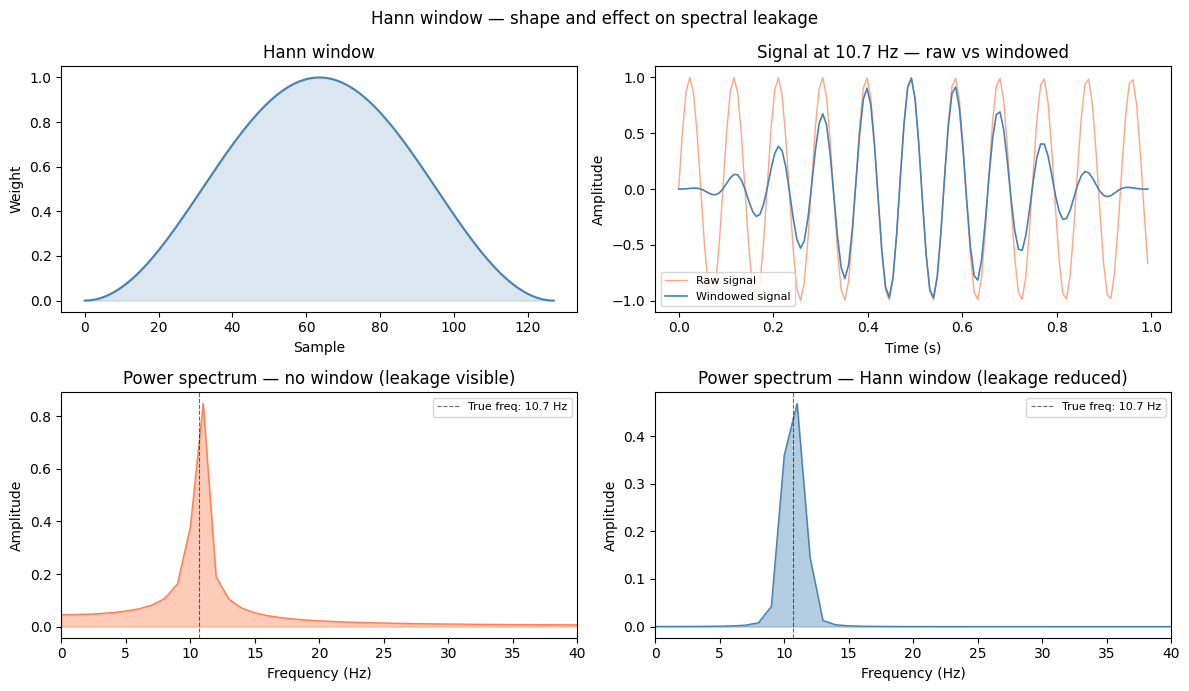

In [7]:
def plot_hann_window(N=128):
    hann = windows.hann(N)
    t = np.arange(N)

    # --- example signal with spectral leakage ---
    fs = 128
    duration = N / fs
    t_sig = np.linspace(0, duration, N, endpoint=False)
    freq = 10.7  # non-integer bin frequency to show leakage
    signal = np.sin(2 * np.pi * freq * t_sig)

    windowed   = signal * hann
    fft_raw    = np.abs(np.fft.rfft(signal))   / (N / 2)
    fft_hann   = np.abs(np.fft.rfft(windowed)) / (N / 2)
    freqs      = np.fft.rfftfreq(N, 1 / fs)

    fig, axes = plt.subplots(2, 2, figsize=(12, 7))

    # --- top left: hann window shape ---
    axes[0, 0].plot(t, hann, color='steelblue', linewidth=1.5)
    axes[0, 0].fill_between(t, hann, alpha=0.2, color='steelblue')
    axes[0, 0].set_title('Hann window')
    axes[0, 0].set_xlabel('Sample')
    axes[0, 0].set_ylabel('Weight')

    # --- top right: raw vs windowed signal ---
    axes[0, 1].plot(t_sig, signal,   color='coral',     linewidth=1.0,
                    alpha=0.7, label='Raw signal')
    axes[0, 1].plot(t_sig, windowed, color='steelblue',  linewidth=1.2,
                    label='Windowed signal')
    axes[0, 1].set_title(f'Signal at {freq} Hz — raw vs windowed')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].legend(fontsize=8)

    # --- bottom left: spectrum without windowing ---
    axes[1, 0].fill_between(freqs, fft_raw, alpha=0.4, color='coral')
    axes[1, 0].plot(freqs, fft_raw, color='coral', linewidth=1.0)
    axes[1, 0].axvline(freq, color='black', linestyle='--',
                       linewidth=0.8, alpha=0.6, label=f'True freq: {freq} Hz')
    axes[1, 0].set_title('Power spectrum — no window (leakage visible)')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Amplitude')
    axes[1, 0].set_xlim(0, 40)
    axes[1, 0].legend(fontsize=8)

    # --- bottom right: spectrum with hann window ---
    axes[1, 1].fill_between(freqs, fft_hann, alpha=0.4, color='steelblue')
    axes[1, 1].plot(freqs, fft_hann, color='steelblue', linewidth=1.0)
    axes[1, 1].axvline(freq, color='black', linestyle='--',
                       linewidth=0.8, alpha=0.6, label=f'True freq: {freq} Hz')
    axes[1, 1].set_title('Power spectrum — Hann window (leakage reduced)')
    axes[1, 1].set_xlabel('Frequency (Hz)')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_xlim(0, 40)
    axes[1, 1].legend(fontsize=8)

    plt.suptitle('Hann window — shape and effect on spectral leakage', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_hann_window(N=128)